# Introduction and Illustration to the Toy Model

As discussed in the paper, we aim to study the general transition in branching-splitting coalescence processes by considering a simple toy model. We set $K$ to be the carrying capacity of the system, and denote the birth rate $\lambda$ and death rate $\mu$. These are respectively given below:

$$n \xrightarrow[\lambda_{n} = n]{} n + 1 \qquad n \xrightarrow[\mu_{n} = \frac{n(n-1)}{K}]{} n - 1 $$

Formally, this problem is CTMC on the state space $\mathbb{N}$ with the infinitesimal generator $Q$ given by:

$$Q=\begin{pmatrix}
-(\lambda_{1}) & \lambda_{1} & 0 & 0 & \cdots \\
\mu_{2} & -(\lambda_{2}+\mu_{2}) & \lambda_{2} & 0 & \cdots \\
0 & \mu_{3} & -(\lambda_{3}+\mu_{3}) & \lambda_{3} & \cdots \\
0 & 0 & \mu_{4} & -(\lambda_{4}+\mu_{4}) & \ddots \\
\vdots & \vdots & \vdots & \ddots & \ddots
\end{pmatrix}
$$

In this notebook, we provide the code for Montecarlo simulations for this process, along with some discussion.


In [106]:
import random 
import matplotlib
from matplotlib import pyplot as plt 
import numpy as np
import math
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from math import sqrt
import pandas as pd
rng = random.Random(1122) 

In [107]:
def time_step(K, t = 0, number_of_particles = 1):
    """A function that simulates a the process over a small time step dt."""
    birth_rate = number_of_particles
    death_rate =  (number_of_particles * (number_of_particles - 1))/K
    total_rate = death_rate + birth_rate
    U  = rng.uniform(0,1)                  # random draw in [0,1]
    dt = - (1/total_rate) * math.log(1 - U)      # dt distributed exponentially with parameter lam = total_rate
    seed = rng.random()
    if seed < birth_rate/total_rate:
        number_of_particles += 1
    else:
        number_of_particles -= 1
    return (t+dt, number_of_particles)

In [124]:
def trial(T,K):
    """A trial experiment, running time_step over some interval [0,T]."""
    t,n=0.0,1
    ts=[t]; xs=[n]
    while t<T:
        t,n = time_step(K, t,n); ts.append(t); xs.append(n)
    return np.array(ts), np.array(xs)

As discussed in the paper, if one ignores initial stochasticity in the early stages of the process, from the microscopic to the mesoscopic scale $n_{0}$, one can derive the mean field solution.

In [109]:
def mean_field(t,N):
    return N/(1+(N-1)*np.e**(-t))

In [125]:
K = 5000 
filename = "../PRL_Data/Exact_Solution_N5000.csv"
data = pd.read_csv(filename)
t = data["Time (s)"]
exact = data["N_of_Particles"]  

def montecarlo(n):
    """Generates a plot overlaying the exact solution, mean field solution and n realizations."""
    paths = {i: trial(20, 5000) for i in range(n)}
    for path in paths:
        plt.plot(paths[path][0],paths[path][1], color = 'black', linestyle='dotted',  linewidth=0.5)
    time = np.linspace(0,20,200)
    plt.plot(time, mean_field(time, K), color = 'red', linestyle='solid',  linewidth=1, label = 'Mean Field Solution')
    plt.plot(time, exact, color = 'blue', linestyle='solid',  linewidth=1, label = r'$\mathbb{E}[X_t]$')
    plt.xlabel('time (s)')
    plt.ylabel('n')
    plt.legend()
    plt.show()
    return paths

Below, we plot the superposition of both the exact solution, as computed using the method of uniformization, the mean field solution and a selection of 5 realizations. As the figure makes clear, the early-time evolution is dominated by stochasticity and when n is small, the moments are well approximated by a pure branching process. In fact, this early-time stochasticity manifests primarily as
a random time shift: most trajectories follow the same deterministic curve but are displaced horizontally depending on their random escape time from the low-n region.

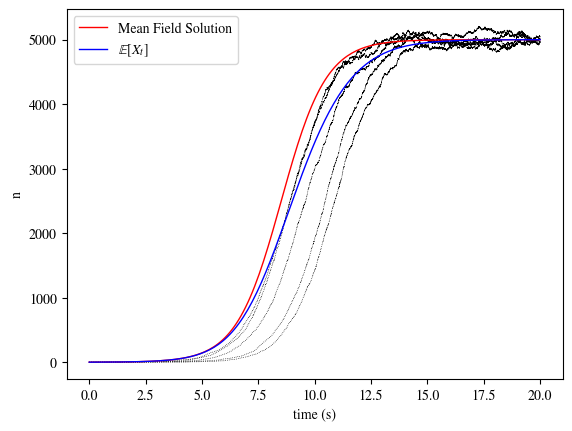

In [111]:
paths = montecarlo(5)

This motivates the following: consider some mesoscopic population size $1 ≪ n_{0} ≪ K$ which will act as a boundary to the stochastic and deterministic regimes. Then, by considering corrections to account for recombinations prior to the rank $n_{0}$ and the noise in the deterministic region one can, in theory, obtain the moments of the particle count to arbitrary precision. The figure below graphically illustrates this convolution, providing examples of both types of paths.

/var/folders/23/tqx9tw093p77x3x_jc51vdh80000gn/T/ipykernel_29284/1232645155.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


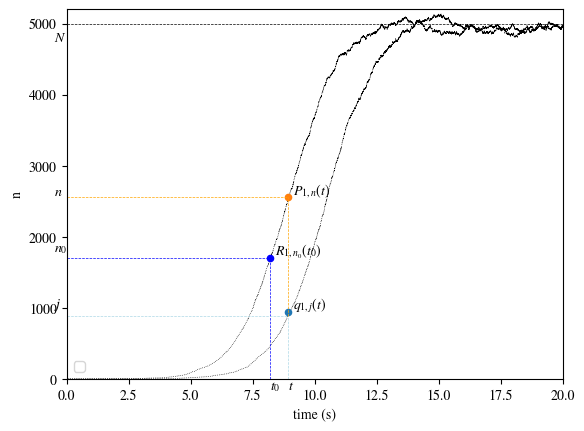

In [123]:
plt.plot(paths[4][0], paths[4][1],
                 color='black', linestyle='dotted', linewidth=0.5)
plt.plot(paths[2][0], paths[2][1],
                 color='black', linestyle='dotted', linewidth=0.5)

plt.xlim(0, 20)
plt.ylim(0, 5200)

x_r1 = 8.2
y_r1 = 1700

plt.scatter(x_r1, y_r1, s=20, zorder=2, color = 'blue')

plt.plot([0, x_r1], [y_r1, y_r1], linewidth=0.5, color= 'blue', linestyle = 'dashed')
plt.plot([x_r1, x_r1], [0, y_r1], linewidth=0.5, color= 'blue', linestyle = 'dashed')


plt.text(x_r1 + 0.2, y_r1 + 50, r'$R_{1, n_0}(t_0)$')


plt.text(-0.5, y_r1 + 40, r'$n_0$', ha='left', va='bottom')


x_q = 8.9122866
y_q = 940
x_r2 = 8.9122866
y_r2 = 2555

plt.scatter(x_q, y_q, s=20, zorder=2)
plt.scatter(x_r2, y_r2, s=20, zorder=2)
plt.plot([0, 20], [5000,5000], linewidth=0.5, color= 'black', linestyle = 'dashed')
plt.plot([0, x_q], [890,890], linewidth=0.5, color= 'lightblue', linestyle = 'dashed')
plt.plot([0, x_r2], [y_r2, y_r2], linewidth=0.5, color= 'orange', linestyle = 'dashed')
plt.plot([x_r2, x_r2], [0,890], linewidth=0.5, color= 'lightblue', linestyle = 'dashed')
plt.plot([x_r2, x_r2], [890, y_r2], linewidth=0.5, color= 'orange', linestyle = 'dashed')

plt.text(x_r2 + 0.2, y_r2 + 50, r'$P_{1,n}(t)$')
plt.text(x_q+0.2, y_q + 50, r'$q_{1,j}(t)$')

plt.text(x_r2, -190, r'$t$', ha='left', va='bottom')
plt.text(-0.5, y_q -10, r'$j$', ha='left', va='bottom')
plt.text(-0.5, y_r2 -10, r'$n$', ha='left', va='bottom')

y_mid = -100
plt.text(x_r1 , y_mid, r'$t_{0}$', ha='left', va='center')
plt.text(-0.5 ,4800, r'$N$', ha='left', va='center')

plt.xlabel('time (s)')
plt.ylabel('n')
plt.legend()
plt.show()
